In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from collections import Counter
from PIL import Image
from tqdm import tqdm
import zipfile
import shutil
from PIL import Image
import seaborn as sns
import gc

In [8]:
print(os.getcwd())
my_dir = os.getcwd()
zip_file_path = os.path.join(my_dir, "archive.zip")
extract_path = os.path.join(my_dir, "raw-img")



C:\Users\ahlad\OneDrive\Documents\NS_zadanie_2\NS_jupyter_2


In [9]:
print(my_dir)

C:\Users\ahlad\OneDrive\Documents\NS_zadanie_2\NS_jupyter_2


In [10]:
if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(my_dir)
    print("Extraction complete.")

<h1>   Extrahovanie Kategórií </h1>

Sledujeme základné rozdelenie tried na základe početností.

In [11]:
def get_image_counts(base_path):
    image_counts = defaultdict(int)
    for root, dirs, files in os.walk(base_path):
        if files:  # Only count if there are images in the folder
            # Remove the base_path from the root to get the relative path
            category = root.replace(base_path, "").strip(os.sep)
            # Remove the "raw-img" part if it exists in the category name
            #category = category.replace("raw-img", "").strip(os.sep)
            image_counts[category] += len(files)
    return image_counts

# Fixing the path
base_path = os.path.join(my_dir, extract_path)  # Using os.path.join to combine paths
print(base_path)
print(my_dir)
print(extract_path)
# Get image counts for all sub-subfolders
image_counts = get_image_counts(base_path)

# Remove the first key (subfolders) as per your comment
first_key = next(iter(image_counts))
#image_counts.pop(first_key)

categories = sorted(image_counts.keys())

print(categories)
# Display category image counts
print("\nImage counts per category:")
for cat, count in image_counts.items():
    print(f"{cat}: {count}")


C:\Users\ahlad\OneDrive\Documents\NS_zadanie_2\NS_jupyter_2\raw-img
C:\Users\ahlad\OneDrive\Documents\NS_zadanie_2\NS_jupyter_2
C:\Users\ahlad\OneDrive\Documents\NS_zadanie_2\NS_jupyter_2\raw-img
['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo']

Image counts per category (including sub-subfolders):
cane: 4863
cavallo: 2623
elefante: 1446
farfalla: 2112
gallina: 3098
gatto: 1668
mucca: 1866
pecora: 1820
ragno: 4821
scoiattolo: 1862


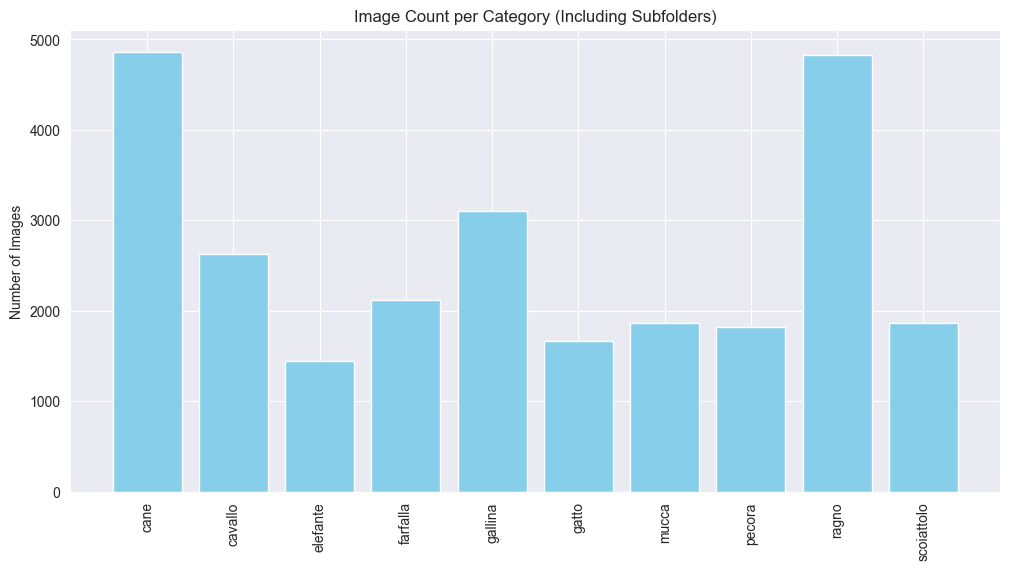

In [12]:
plt.figure(figsize=(12, 6))
plt.bar(image_counts.keys(), image_counts.values(), color='skyblue')
plt.xticks(rotation=90)
plt.ylabel("Number of Images")
plt.title("Image Count per Category")
plt.show()

C:\Users\ahlad\OneDrive\Documents\NS_zadanie_2\NS_jupyter_2\raw-img\cane\OIF-e2bexWrojgtQnAPPcUfOWQ.jpeg
C:\Users\ahlad\OneDrive\Documents\NS_zadanie_2\NS_jupyter_2\raw-img\cavallo\OIP---MGqQIhmz3OEPYP-46_xwHaFj.jpeg
C:\Users\ahlad\OneDrive\Documents\NS_zadanie_2\NS_jupyter_2\raw-img\elefante\e032b10b2df21c22d2524518b7444f92e37fe5d404b0144390f8c07aa5ecb6_640.jpg
C:\Users\ahlad\OneDrive\Documents\NS_zadanie_2\NS_jupyter_2\raw-img\farfalla\e030b20928e90021d85a5854ee454296eb70e3c818b413449df6c87ca3ed_640.jpg
C:\Users\ahlad\OneDrive\Documents\NS_zadanie_2\NS_jupyter_2\raw-img\gallina\10.jpeg
C:\Users\ahlad\OneDrive\Documents\NS_zadanie_2\NS_jupyter_2\raw-img\gatto\1.jpeg
C:\Users\ahlad\OneDrive\Documents\NS_zadanie_2\NS_jupyter_2\raw-img\mucca\OIP---lAIbDlHKmejDpqrXq6vAAAAA.jpeg
C:\Users\ahlad\OneDrive\Documents\NS_zadanie_2\NS_jupyter_2\raw-img\pecora\e032b5082ef61c22d2524518b7444f92e37fe5d404b0144390f8c078a0eabd_640.jpg
C:\Users\ahlad\OneDrive\Documents\NS_zadanie_2\NS_jupyter_2\raw-img\

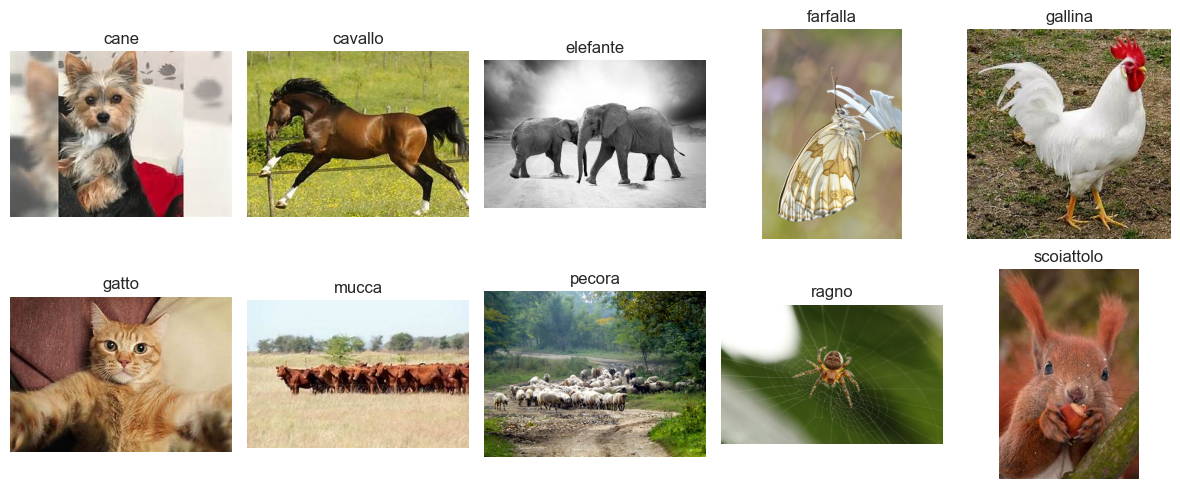

In [13]:


fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

# Iterate over the first 10 categories
for i, cat in enumerate(categories[:10]):
    cat_path = os.path.join(extract_path, cat)  # Fixing the path concatenation
    img_files = [f for f in os.listdir(cat_path) if f.lower().endswith(('png', 'jpg', 'jpeg'))]
    if img_files:  # Ensure the category has images
        img_path = os.path.join(cat_path, img_files[0])
        img = Image.open(img_path)  # This should now work
        print(img_path)
        axes[i].imshow(img)
        axes[i].set_title(cat)
        axes[i].axis("off")

plt.tight_layout()
plt.show()

<h1> DataFrame preparatio </h1>
Berieme v úvahu iba png, jpeg, jpg <Br>
Pozeráme či RGB nieje náhodou skryté Greyscale <Br>
Nechávame iba RBG
Kontrolujeme či veľké obrázky sú kvalitné alebo sú to malé zvieratá na veľkom pozadí
Získaný dataframe ukladáme do csv, s ktorým neskôr pracujeme pri samotnom modely.

In [14]:
def check_rgb_grayscale(img_path):

    with Image.open(img_path) as img:

        if img.mode != 'RGB':
            #print(f"The image {img_path} is not in RGB mode. It's in {img.mode} mode.")
            return False

        pixels = img.load()

        for y in range(img.height):
            for x in range(img.width):
                r, g, b = pixels[x, y]  # Get RGB values for the pixel
                if r != g or g != b:
                    return False



        return True

In [15]:
label_dict = {
    "cane": 0,
     "cavallo": 1 ,
     "elefante": 2 ,
     "farfalla": 3 ,
     "gallina": 4 ,
     "gatto": 5 ,
     "mucca": 6 ,
     "pecora": 7,
     "ragno" : 8,
     "scoiattolo": 9,

}



In [16]:
def is_rgb_image(img_path):
    try:
        with Image.open(img_path) as img:
            return img.mode == 'RGB'
    except Exception as e:
        print(f"Error opening image {img_path} for mode check: {e}")
        return False


def process_image(img_path):
    try:

        if not is_rgb_image(img_path):
            return None

        image_size = os.path.getsize(img_path)

        with Image.open(img_path) as img:

            width, height = img.size
            image_type = img.format

        subdirectory_name = os.path.basename(os.path.dirname(img_path))
        label = label_dict.get(subdirectory_name, -1)

        return {
            'subdirectory_name': subdirectory_name,
            'image_name': os.path.basename(img_path),
            'image_size_bytes': image_size,
            'width': width,
            'height': height,
            'image_type': image_type,
            'label': label,
        }

    except Exception as e:
        print(f"Error processing image {img_path}: {e}")
        return None

def process_images_sequentially(dataset_path):
    image_data = []

    image_paths = []
    for root, dirs, files in os.walk(dataset_path):
        for img_file in files:
            if img_file.lower().endswith(('png', 'jpg', 'jpeg')):
                img_path = os.path.join(root, img_file)
                image_paths.append(img_path)

    # Process images sequentially
    for idx, img_path in enumerate(image_paths):
        result = process_image(img_path)
        if result:
            image_data.append(result)

        if (idx + 1) % 1000 == 0:
            print(f"Processed {idx + 1} images...")

        if (idx + 1) % 10000 == 0:
            gc.collect()
    return image_data

dataset_path = extract_path  # Replace with your path
image_data = process_images_sequentially(dataset_path)

image_df = pd.DataFrame(image_data)

print(image_df.head())

Processed 1000 images...
Processed 2000 images...
Processed 3000 images...
Processed 4000 images...
Processed 5000 images...
Processed 6000 images...
Processed 7000 images...
Processed 8000 images...
Processed 9000 images...
Processed 10000 images...
Processed 11000 images...
Processed 12000 images...
Processed 13000 images...
Processed 14000 images...
Processed 15000 images...
Processed 16000 images...
Processed 17000 images...
Processed 18000 images...
Processed 19000 images...
Processed 20000 images...
Processed 21000 images...
Processed 22000 images...
Processed 23000 images...
Processed 24000 images...
Processed 25000 images...
Processed 26000 images...
  subdirectory_name                           image_name  image_size_bytes  \
0              cane      OIF-e2bexWrojgtQnAPPcUfOWQ.jpeg              9451   
1              cane  OIP---A27bIBcUgX1qkbpZOPswHaFS.jpeg              9334   
2              cane  OIP---cByAiEbIxIAleGo9AqOQAAAA.jpeg              8966   
3              cane  

In [17]:
image_df.to_csv('my_data.csv', index=False)

In [18]:
image_df = pd.read_csv('my_data.csv')
print(image_df)
dataset_path = extract_path

      subdirectory_name                           image_name  \
0                  cane      OIF-e2bexWrojgtQnAPPcUfOWQ.jpeg   
1                  cane  OIP---A27bIBcUgX1qkbpZOPswHaFS.jpeg   
2                  cane  OIP---cByAiEbIxIAleGo9AqOQAAAA.jpeg   
3                  cane  OIP---ZIdwfUcJeVxnh47zppcQHaFj.jpeg   
4                  cane  OIP---ZRsOF7zsMqhW30WeF8-AHaFj.jpeg   
...                 ...                                  ...   
26123        scoiattolo  OIP-_U7JiIoYjbWPqmmmmdsvJwHaF5.jpeg   
26124        scoiattolo  OIP-_VBkNQd_MZI4xoemUb-FtAHaE7.jpeg   
26125        scoiattolo  OIP-_WyHKgREia-4VijlL6DNswHaFj.jpeg   
26126        scoiattolo  OIP-_xFGMN0UbYduHdiXQ1maZAHaIF.jpeg   
26127        scoiattolo  OIP-_XkUFCI2duAyKDD9utKQzgHaFc.jpeg   

       image_size_bytes  width  height image_type  label  
0                  9451    300     225       JPEG      0  
1                  9334    300     214       JPEG      0  
2                  8966    153     300       JPEG     

In [19]:
def get_unique_counts(df, column_name):

    unique_counts = df[column_name].value_counts().to_dict()
    return unique_counts

In [20]:
color_mode_counts = get_unique_counts(image_df, 'height')

print("\nColor mode counts:")
for color_mode, count in color_mode_counts.items():
    print(f"{color_mode}: {count}")


Color mode counts:
300: 4870
225: 4401
200: 3295
169: 1049
426: 690
199: 586
240: 418
188: 395
221: 300
201: 290
214: 243
226: 241
194: 190
640: 187
202: 169
216: 145
210: 135
213: 129
220: 124
219: 120
480: 116
228: 114
206: 113
209: 113
223: 112
224: 112
218: 110
197: 109
230: 107
235: 106
180: 105
168: 104
232: 101
207: 100
211: 100
195: 99
204: 98
233: 96
251: 94
212: 90
237: 85
215: 82
157: 82
263: 81
150: 81
425: 80
190: 77
245: 73
238: 73
222: 72
249: 72
217: 72
267: 70
264: 69
187: 68
247: 68
208: 68
256: 67
360: 66
198: 66
229: 66
185: 66
254: 64
192: 64
252: 64
244: 63
242: 62
261: 61
283: 60
236: 59
231: 58
427: 57
203: 56
205: 55
257: 55
428: 53
250: 53
280: 53
259: 53
196: 52
246: 52
271: 52
273: 51
239: 50
266: 49
234: 49
241: 48
255: 48
299: 47
423: 47
177: 46
268: 46
227: 45
183: 45
278: 44
243: 42
276: 42
248: 42
164: 42
287: 42
275: 41
193: 41
290: 40
253: 40
142: 39
285: 39
294: 38
288: 37
182: 36
178: 36
282: 35
160: 35
260: 35
295: 34
269: 34
292: 34
184: 33
176: 

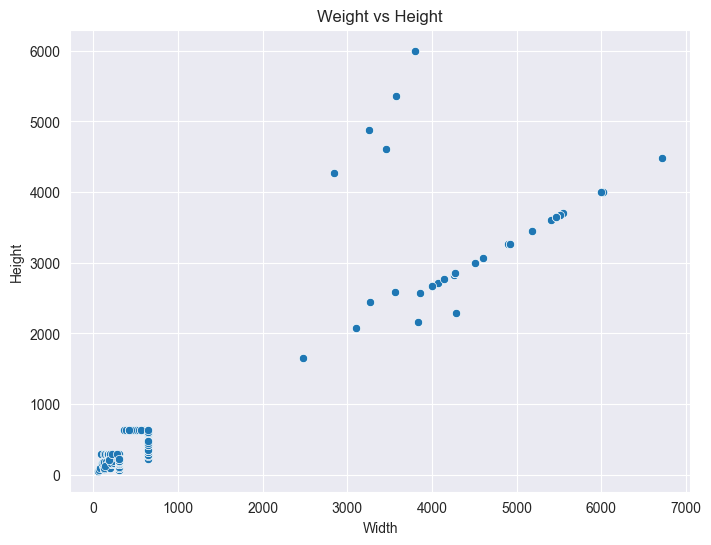

In [21]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='width', y='height', data=image_df)
plt.title('Weight vs Height')
plt.ylabel('Height')
plt.xlabel('Width')
plt.grid(True)
plt.show()

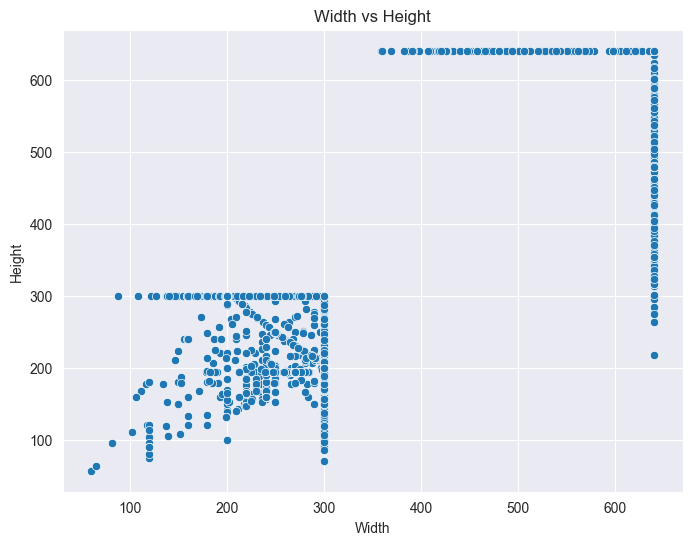

In [22]:
filtered_df = image_df[(image_df['width'] <= 1000) & (image_df['height'] <= 1000)]

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x='width', y='height', data=filtered_df)
plt.title('Width vs Height')
plt.ylabel('Height')
plt.xlabel('Width')
plt.grid(True)
plt.show()

In [23]:
filtered_df = image_df[(image_df['height'] > 1000) | (image_df['width'] > 1000)]

count = filtered_df.shape[0]
print(f"Number of entries with height or width > 1000: {count}")

summary = filtered_df['subdirectory_name'].value_counts()

print("\nCount of large images per subdirectory:")
print(summary)

Number of entries with height or width > 1000: 42

Count of large images per subdirectory:
subdirectory_name
gatto    42
Name: count, dtype: int64


In [24]:
filtered_df = image_df[(image_df['width'] < 64) & (image_df['height'] < 64)]
count = filtered_df.shape[0]
print(f"Number of entries with height or width < 64: {count}")
filtered_df = image_df[(image_df['width'] < 128) & (image_df['height'] < 128)]
count = filtered_df.shape[0]
print(f"Number of entries with height or width < 128: {count}")

Number of entries with height or width < 64: 5
Number of entries with height or width < 128: 20


gatto
abdu-rahman-2934-unsplash.jpg
gatto
anete-lusina-609858-unsplash.jpg
gatto
anselmo-stevin-laksito-387930-unsplash.jpg
gatto
cat-mapper-max-ogden-204436-unsplash.jpg
gatto
cel-lisboa-73965-unsplash.jpg
gatto
chinda-sam-164936-unsplash.jpg
gatto
chinda-sam-413882-unsplash.jpg
gatto
christian-wright-386668-unsplash.jpg
gatto
erik-jan-leusink-126918-unsplash.jpg
gatto
erik-jan-leusink-144775-unsplash.jpg
gatto
erik-jan-leusink-180382-unsplash.jpg
gatto
erik-jan-leusink-378147-unsplash.jpg
gatto
erik-jan-leusink-427699-unsplash.jpg
gatto
erik-jan-leusink-561776-unsplash.jpg
gatto
freddie-marriage-40645-unsplash.jpg
gatto
hannah-troupe-349131-unsplash.jpg
gatto
jannik-selz-335261-unsplash.jpg
gatto
jonas-vincent-2717-unsplash.jpg
gatto
jose-ros-photo-388605-unsplash.jpg
gatto
josh-couch-475167-unsplash.jpg
gatto
kamonnat-onnom-106416-unsplash.jpg
gatto
kari-shea-471277-unsplash.jpg
gatto
kevin-knezic-254586-unsplash.jpg
gatto
koen-eijkelenboom-353684-unsplash.jpg
gatto
kristin-lopez-41

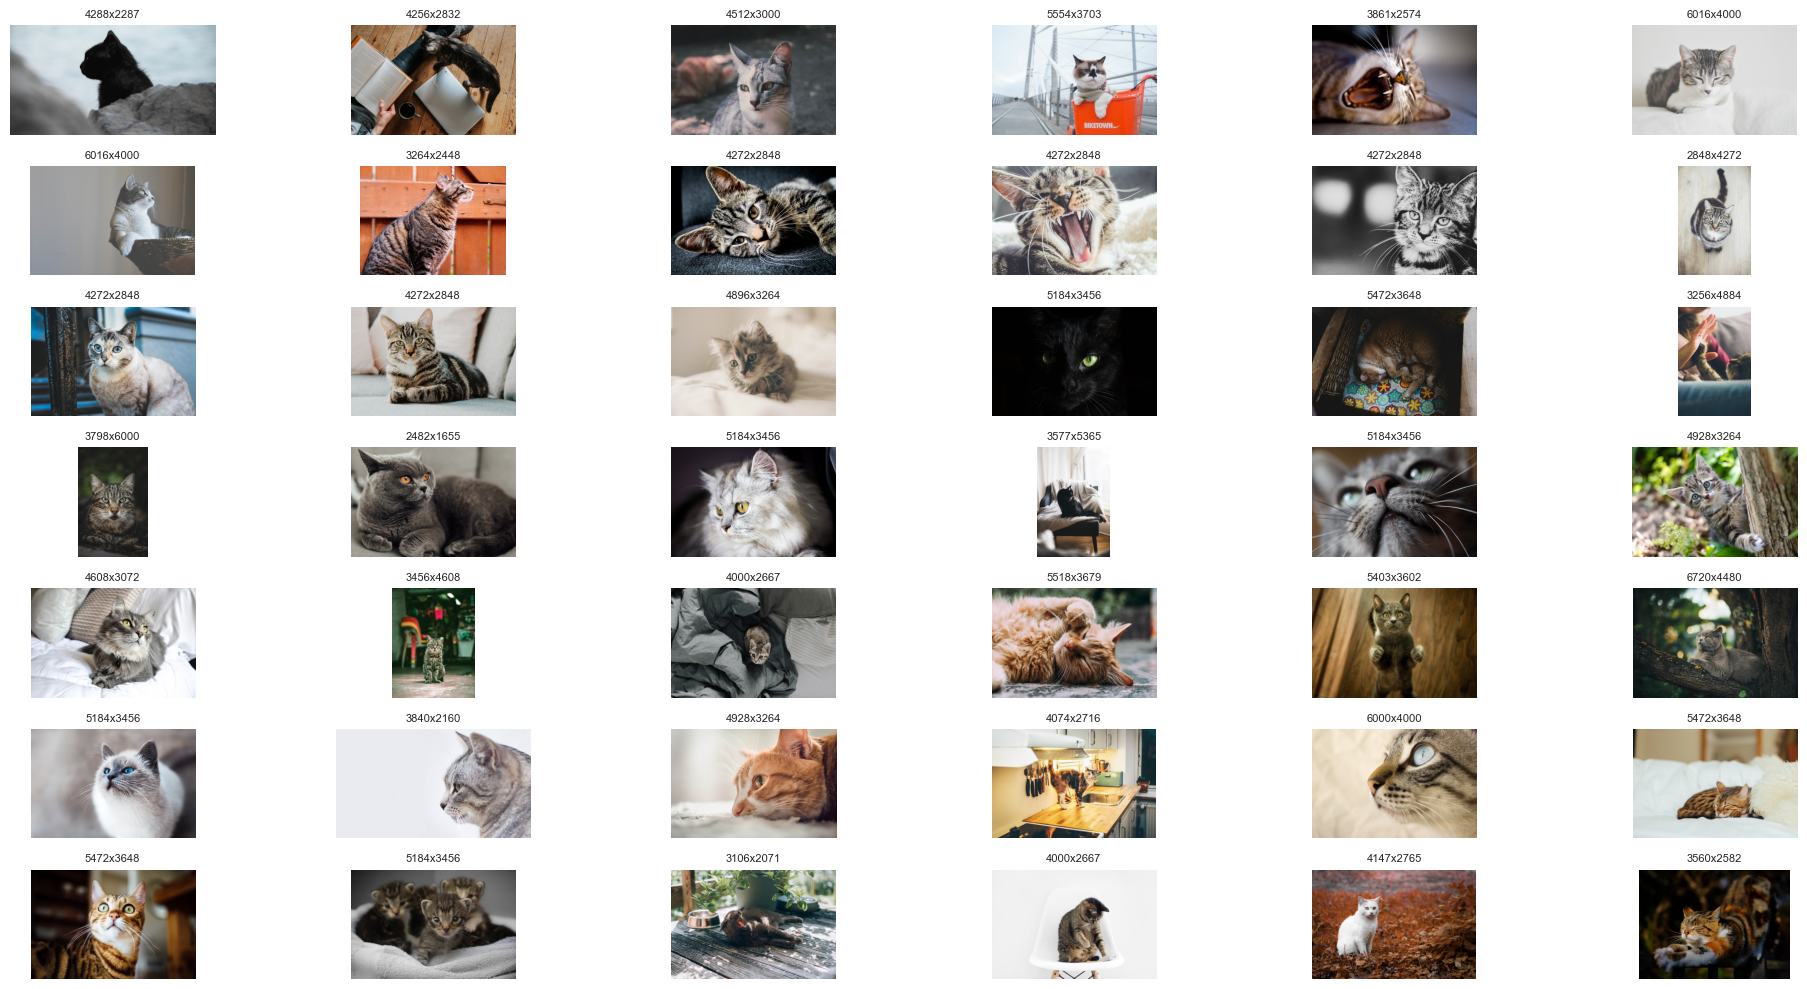

In [26]:
big_images = image_df[(image_df['width'] > 1000) | (image_df['height'] > 1000)]

big_images = big_images.head(50)

fig, axes = plt.subplots(7, 6, figsize=(20, 10))
axes = axes.flatten()

for i, (_, row) in enumerate(big_images.iterrows()):
    if i >= len(axes):
        break

    subdir = row['subdirectory_name'].strip()
    print(subdir)
    filename = row['image_name']
    print(filename)
    full_path = os.path.join(my_dir, extract_path, subdir, filename)

    if os.path.exists(full_path):
        try:
            img = Image.open(full_path)

            # Resize image to 25% of original size
            new_size = (img.width // 4, img.height // 4)
            img = img.resize(new_size)

            axes[i].imshow(img)
            axes[i].set_title(f"{row['width']}x{row['height']}", fontsize=8)
            axes[i].axis("off")

        except Exception as e:
            print(f"Error loading image {full_path}: {e}")
            axes[i].axis("off")
            axes[i].set_title("Error")
    else:
        print(f"Missing file: {full_path}")
        axes[i].axis("off")
        axes[i].set_title("Missing")

plt.tight_layout()
plt.show()

<h1>Vyzualizácia nesprávne určených tried.</h1>

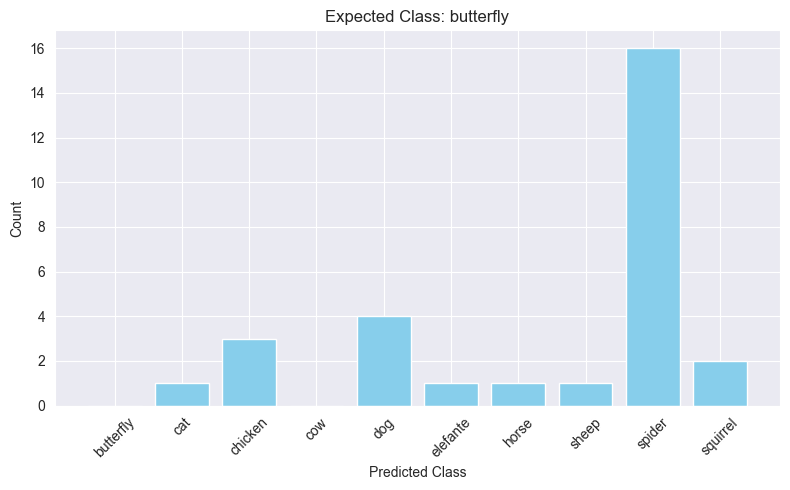

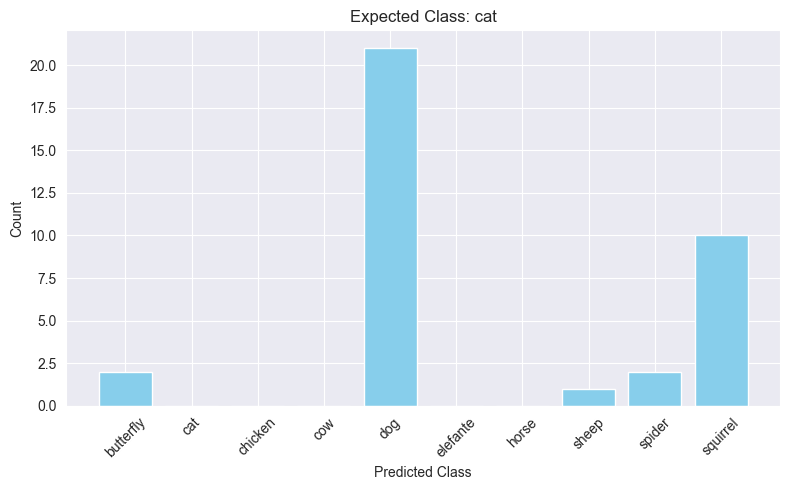

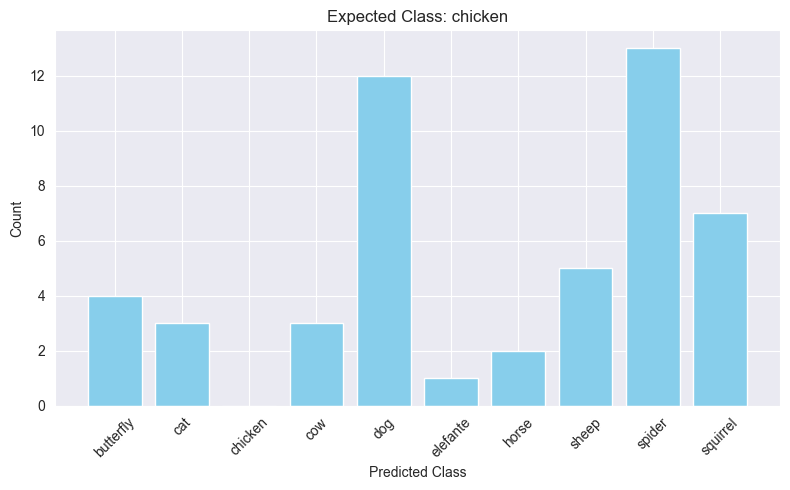

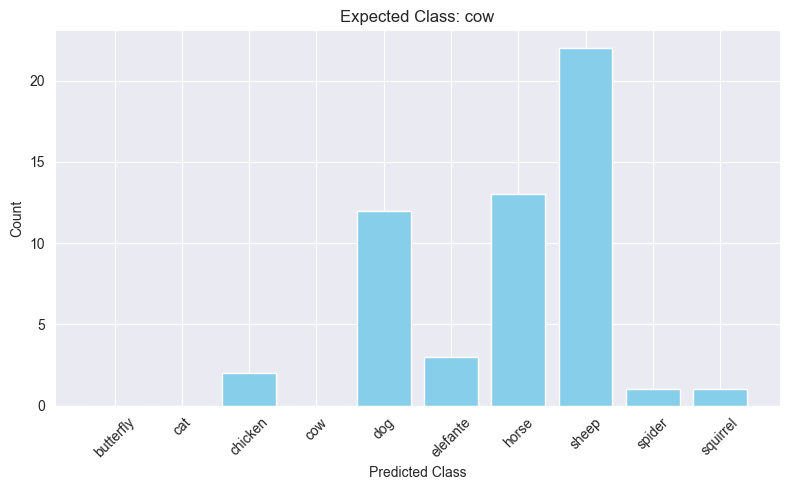

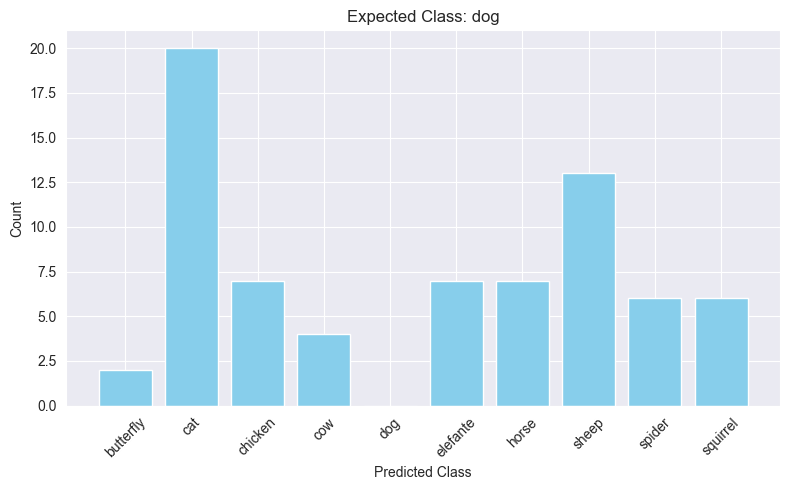

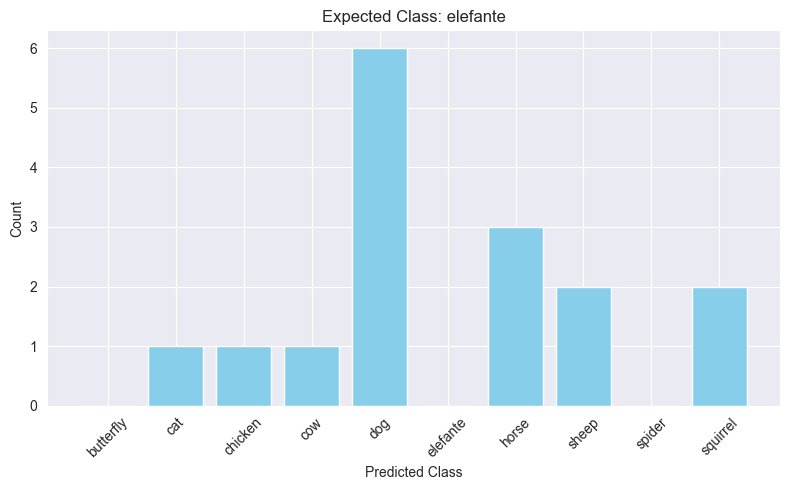

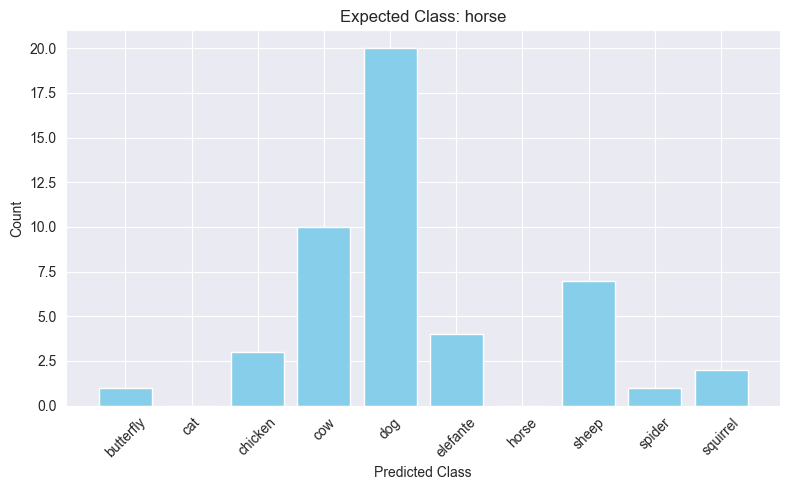

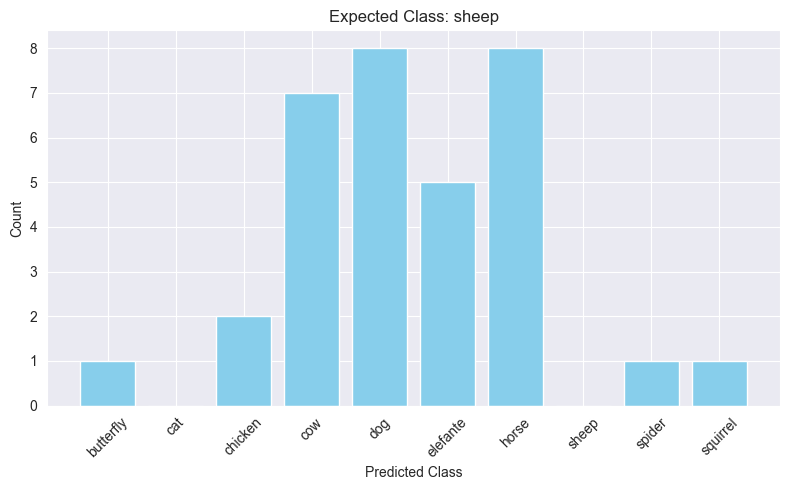

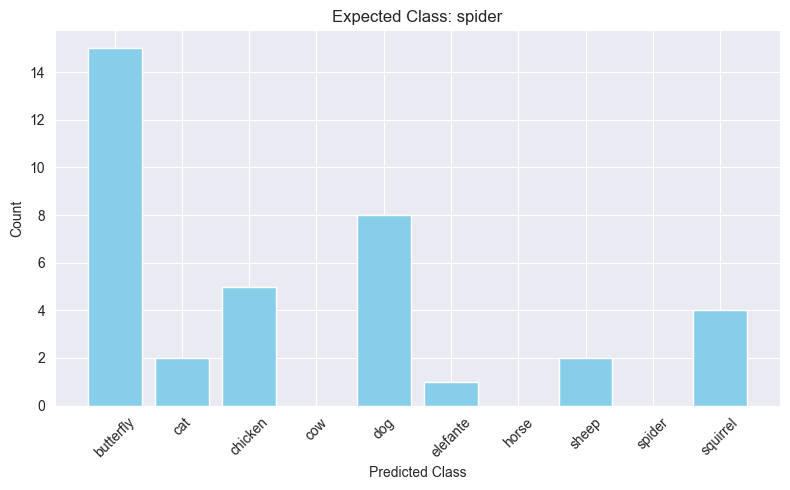

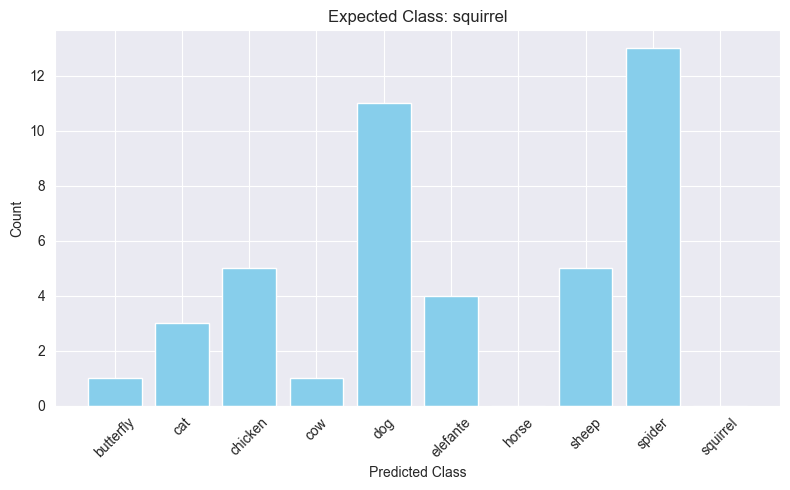

In [13]:
import pandas as pd
import matplotlib.pyplot as plt


translation = {
    "mucca": "cow",
    "gatto": "cat",
    "cavallo": "horse",
    "cane": "dog",
    "farfalla": "butterfly",
    "ragno": "spider",
    "pecora": "sheep",
    "gallina": "chicken",
    "scoiattolo": "squirrel"
}


df = pd.read_csv("Best_A.csv")

df["Expected"] = df["Expected"].apply(lambda x: translation.get(x, x) if isinstance(x, str) else x)
df["Predicted"] = df["Predicted"].apply(lambda x: translation.get(x, x) if isinstance(x, str) else x)

all_classes = sorted(set(df['Expected'].dropna().unique()) | set(df['Predicted'].dropna().unique()))

for cls in all_classes:
    subset = df[df['Expected'] == cls]

    pred_counts = {pred: 0 for pred in all_classes}
    for _, row in subset.iterrows():
        pred_counts[row['Predicted']] = row['Count']

    # Plot
    plt.figure(figsize=(8, 5))
    plt.bar(pred_counts.keys(), pred_counts.values(), color='skyblue')
    plt.title(f"Expected Class: {cls}")
   #plt.xlabel("Predicted Class")
    #plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


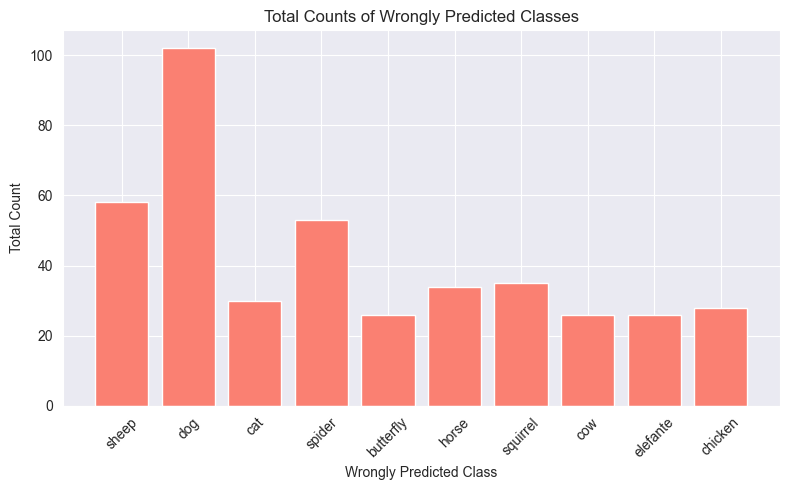

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Translation dictionary from Italian to English
translation = {
    "mucca": "cow",
    "gatto": "cat",
    "cavallo": "horse",
    "cane": "dog",
    "farfalla": "butterfly",
    "ragno": "spider",
    "pecora": "sheep",
    "gallina": "chicken",
    "scoiattolo": "squirrel"
}

# Load the CSV file
df = pd.read_csv("Best_A.csv")  # Replace with your actual file path

# Translate Expected and Predicted columns only if they are strings
df["Expected"] = df["Expected"].apply(lambda x: translation.get(x, x) if isinstance(x, str) else x)
df["Predicted"] = df["Predicted"].apply(lambda x: translation.get(x, x) if isinstance(x, str) else x)

# Filter the data for wrongly predicted classes (Expected != Predicted)
wrong_predictions = df[df['Expected'] != df['Predicted']]

# Create a dictionary to store the sum of counts for each wrongly predicted class
wrong_pred_counts = {}

# Sum the counts for wrongly predicted classes
for _, row in wrong_predictions.iterrows():
    if row['Predicted'] not in wrong_pred_counts:
        wrong_pred_counts[row['Predicted']] = 0
    wrong_pred_counts[row['Predicted']] += row['Count']

# Plot the total counts for wrongly predicted classes
plt.figure(figsize=(8, 5))
plt.bar(wrong_pred_counts.keys(), wrong_pred_counts.values(), color='salmon')
plt.title("Total Counts of Wrongly Predicted Classes")
plt.xlabel("Wrongly Predicted Class")
plt.ylabel("Total Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
